In [1]:
#Don't Delete this cell, it is essential for importing all the required symbols and functions
import sys
sys.path.insert(0, '/home/aayush/Documents/Generic/Horndeski')

# sympy
from sympy import Function, symbols, simplify
from sympy.printing.latex import LatexPrinter
from IPython.display import display, Math

# all horndeski symbols in one go
from horndeski.symbols import (
    phi_sym, X_sym,
    phi, dphi, ddphi,
    H, dH,
    Mpl, M
)

# background functions
from horndeski.algebra.background import (
    energy_density, pressure,
    KG_coefficients, slow_roll_epsilon,
    substitute_model, klein_gordon,
)

# define V once here
V = Function('V')(phi_sym)
dV = V.diff(phi_sym)

# custom printer
class HorndeskiPrinter(LatexPrinter):
    def _print_Symbol(self, expr):
        mapping = {
            'phi_sym' : r'\phi',
            'X_sym'   : r'X',
            'Mpl'     : r'M_{\rm pl}',
        }
        return mapping.get(expr.name, super()._print_Symbol(expr))

    def _print_Function(self, expr, exp=None):
        mapping = {
            'dphi'  : r'\dot{\phi}',
            'ddphi' : r'\ddot{\phi}',
            'dH'    : r'\dot{H}',
        }
        name = expr.func.__name__
        if name in mapping:
            result = mapping[name]
            if exp is not None:
                result = r'\left(' + result + r'\right)^{' + str(exp) + '}'
            return result
        return super()._print_Function(expr, exp=exp)

def pretty(expr):
    display(Math(HorndeskiPrinter().doprint(expr)))

In [2]:
G2 = X_sym - V
G3 = 0 
G4 = Mpl**2/2 
G5 = 0 

In [ ]:
# Example 3 — k-inflation (uncomment to switch)
# G2 = X_sym**2 / M**4 - V
# G3 = 0 * X_sym
# G4 = Mpl**2/2
# G5 = 0 * X_sym

In [3]:
def show(label, expr):
    result = substitute_model(expr, G2, G3, G4, G5)
    result = result.subs(X_sym, dphi**2/2)
    result = simplify(result)
    print(f"\n{label}")
    pretty(result)

show("FRIEDMANN ", energy_density())
show("RAICHAUDHARI ",pressure())
show("KG", klein_gordon())


FRIEDMANN 


<IPython.core.display.Math object>


RAICHAUDHARI 


<IPython.core.display.Math object>


KG


<IPython.core.display.Math object>

In [4]:
from horndeski.algebra.perturbations import (
    QT, cT2, Qs, cs2, substitute_perturbations
)



res = substitute_perturbations(G2, G3, G4, G5)

print(" QT  (tensor kinetic coefficient)")
pretty(res['QT'])

print("\ncT²  (tensor speed squared)")
pretty(res['cT2'])

print("\nQs  (scalar kinetic coefficient)")
pretty(res['Qs'])

print("\ncs²  (scalar sound speed squared)")
pretty(res['cs2'])

 QT  (tensor kinetic coefficient)


<IPython.core.display.Math object>


cT²  (tensor speed squared)


<IPython.core.display.Math object>


Qs  (scalar kinetic coefficient)


<IPython.core.display.Math object>


cs²  (scalar sound speed squared)


<IPython.core.display.Math object>

In [5]:

from horndeski.codegen.cpp_emitter import emit_model
PATH = '/home/aayush/Documents/Generic/Horndeski' 
emit_model(
    G2, G3, G4, G5,                # the model you defined above
    model_name  = "user model",
    V_expr      = V,
    dV_expr     = dV,
    output_path = f"{PATH}/model_generated.hpp",
    params      = {"Mpl": 1.0, "M": 1e-3},   # set your PHYSICAL M here
)
print("model_generated.hpp written.")

[codegen] Substituting user model model into background equations...
[codegen] Computing perturbation coefficients...
[codegen] Emitting C++ header to /home/aayush/Documents/Generic/Horndeski/model_generated.hpp...
[codegen] Done. Written to: /home/aayush/Documents/Generic/Horndeski/model_generated.hpp
[codegen] Functions emitted:
          Background:    rho_phi, dH_rhs, ddphi_rhs, epsilon_H
          Perturbations: QT, cT2, Qs, cs2
          MS helpers:    z2_over_a2, u2_over_a2
model_generated.hpp written.


In [6]:
import subprocess
r = subprocess.run(["make", "pipeline"], cwd=PATH, capture_output=True, text=True)
print(r.stdout[-2000:])
if r.returncode != 0:
    print("STDERR:\n", r.stderr[-2000:]); raise RuntimeError("pipeline failed")

g++ -O3 -Wall -Wextra -march=native -ffast-math -o background background.cpp
Built: background
g++ -O3 -Wall -Wextra -march=native -ffast-math -o perturbation perturbation.cpp
Built: perturbation
---  background  ---
./background
Inflation ended:
  N_tot=85.6664
  phi=0.543327
  H=3.37581e-06
  epsilon=1.00001
  QT=1
  cT2=1
  Qs=1.00001
  cs2=1
---  perturbation  ---
./perturbation
Loaded 85668 background points, N = 0 to 85.6664
k_star=1.17217e+08 k_min=0.00209166 k_max=3.65767e+29  (decades=32.2427)
Solving 400 modes...
Results at k_star 
  A_s = 1.78385e-09
  n_s = 0.971908
  r   = 0.00364068
  n_T = -0.000477742
---  summary  ---
# Primordial power spectrum summary
# k_star = 117217309.115048
A_s = 1.78385063157065e-09
n_s = 0.97190820582352
r   = 0.00364067626350144
A_T = 6.49442265199129e-12
n_T = -0.000477741639160024
./rescale scalar_spectrum.dat
pivot k/k_star=0.99786  P=1.78385e-09  factor_p=1.22208  -> scalar_spectrum_rescaled.dat (400 rows)
./rescale tensor_spectrum.dat
te

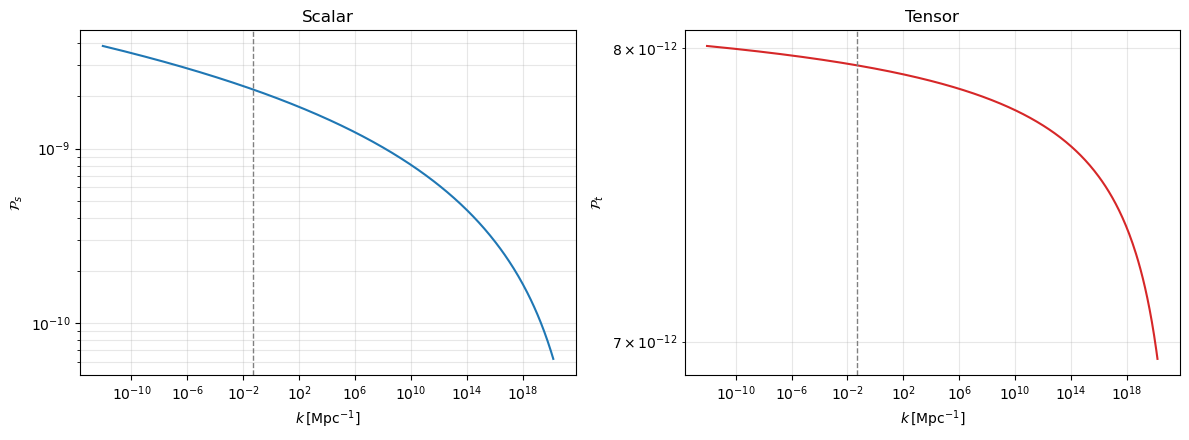

In [7]:
import numpy as np, matplotlib.pyplot as plt
ks, Ps = np.loadtxt(f"{PATH}/scalar_spectrum_rescaled.dat", unpack=True)
kt, Pt = np.loadtxt(f"{PATH}/tensor_spectrum_rescaled.dat", unpack=True)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].loglog(ks, Ps); ax[0].set(xlabel=r'$k\,[\mathrm{Mpc}^{-1}]$', ylabel=r'$\mathcal{P}_s$', title='Scalar')
ax[1].loglog(kt, Pt, 'C3'); ax[1].set(xlabel=r'$k\,[\mathrm{Mpc}^{-1}]$', ylabel=r'$\mathcal{P}_t$', title='Tensor')
for a in ax: a.axvline(0.05, ls='--', c='grey', lw=1); a.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [14]:
subprocess.run("make clean",cwd=PATH, capture_output=True, text=True,shell=True)

CompletedProcess(args='make clean', returncode=0, stdout='rm -f background perturbation rescale\n', stderr='')

In [5]:
# GR sanity check: G2=X-V, G3=0, G4=Mpl^2/2, G5=0 
# Expected:
#   QT   = Mpl^2
#   cT^2 = 1
#   Qs   = dphi^2 / (2*H^2)   (= epsilon * Mpl^2)
#   cs^2 = 1

G2_GR = X_sym - V
G3_GR = 0 * X_sym
G4_GR = Mpl**2 / 2
G5_GR = 0 * X_sym

res_GR = substitute_perturbations(G2_GR, G3_GR, G4_GR, G5_GR)

print("QT  (should be Mpl^2)")
pretty(res_GR['QT'])

print("\ncT^2  (should be 1)")
pretty(res_GR['cT2'])

print("\nQs  (should be dphi^2 / (2*H^2))")
pretty(res_GR['Qs'])

print("\ncs^2  (should be 1)")
pretty(res_GR['cs2'])

QT  (should be Mpl^2)


<IPython.core.display.Math object>


cT^2  (should be 1)


<IPython.core.display.Math object>


Qs  (should be dphi^2 / (2*H^2))


<IPython.core.display.Math object>


cs^2  (should be 1)


<IPython.core.display.Math object>